Objective:

Process a cleaned CSV containing house heating fuel estimates by census tract, focusing on the share of households using Fuel oil, kerosene, etc., and produce a clean, sortable dataset with percentages.

Key Steps:

Load cleaned CSV data
Imported the data with a Label (Grouping) column and multiple census tract estimate columns.

Select only Estimate columns
Filtered columns to include only those ending with !!Estimate, skipping !!Margin of Error columns to avoid noisy or non-numeric values.

Transform data from wide to long format
Melted the tract columns to a long format, creating one row per (Label (Grouping), tract, county, measure) combination.

Clean numeric values
Removed commas and stray symbols like ± from values before converting to numeric types to avoid parsing errors.

Parse tract, county, and measure info from column names
Extracted tract numbers (including decimals like 2.01), county names, and measure type (always 'Estimate' here) from the melted column names using regex.

Normalize text fields
Stripped whitespace and standardized capitalization of county names for consistent merging.

Create GEOID placeholder
Created a simple GEOID by concatenating county name (no spaces) and tract number, for easy referencing.

Separate Fuel Oil and Total households
Filtered rows where Label (Grouping) is either 'Fuel oil, kerosene, etc.' or 'Total:' to isolate relevant data.

Merge Fuel Oil estimates with Total households
Joined the two datasets on tract and county to align estimates and totals.

Calculate Fuel Oil percentage
Computed the percentage of households using Fuel oil by dividing the estimate by the total households and multiplying by 100, rounding to two decimals.

Sort data by numeric tract
Sorted final data by tract number (including decimal tracts) to ensure logical order.

Export clean dataset
Saved the resulting dataset to a CSV file for further use.

In [64]:
import pandas as pd
import re

# 1. Load the cleaned CSV
data = pd.read_csv("ACSDT5Y2023_HouseHeatingFuel_Clean.csv")

# 2. Identify ONLY columns ending with !!Estimate for census tracts
tract_cols = [col for col in data.columns if "Census Tract" in col and col.endswith("!!Estimate")]

# 3. Melt to long format only on Estimate columns
df_long = data.melt(
    id_vars=['Label (Grouping)'],
    value_vars=tract_cols,
    var_name='tract_col',
    value_name='value'
)

# 4. Clean numeric values before conversion
df_long['value'] = (
    df_long['value']
    .astype(str)
    .str.replace(',', '', regex=False)  # Remove thousands separators
    .str.replace('±', '', regex=False)  # Remove ± signs if any leak through
    .str.strip()
)

df_long['value'] = pd.to_numeric(df_long['value'], errors='coerce')

# 5. Parse tract, county, and measure from column names
def parse_col(col_name):
    tract_match = re.search(r"Census Tract ([\d\.]+);", col_name)
    county_match = re.search(r"; ([^;]+)!!", col_name)
    measure_match = re.search(r"!!(.+)$", col_name)
    
    tract = tract_match.group(1) if tract_match else None
    county = county_match.group(1) if county_match else None
    measure = measure_match.group(1) if measure_match else None
    
    return pd.Series([tract, county, measure])

df_long[['tract', 'county', 'measure']] = df_long['tract_col'].apply(parse_col)

# 6. Strip and normalize fields
df_long['Label (Grouping)'] = df_long['Label (Grouping)'].str.strip()
df_long['tract'] = df_long['tract'].astype(str).str.strip()
df_long['county'] = df_long['county'].str.strip().str.title()  # Normalize capitalization

# 7. Create GEOID placeholder (customize if you want real FIPS codes)
df_long['GEOID'] = df_long['county'].str.replace(" ", "") + df_long['tract']

# 8. Convert tract to float for sorting
df_long['tract_float'] = df_long['tract'].astype(float)

# 9. Extract Fuel oil estimate rows
df_fuel = df_long[
    (df_long['measure'] == 'Estimate') &
    (df_long['Label (Grouping)'] == 'Fuel oil, kerosene, etc.')
].copy()

df_fuel = df_fuel[['tract', 'county', 'GEOID', 'value', 'tract_float']]
df_fuel.rename(columns={'value': 'FuelOilEstimate'}, inplace=True)

# 10. Extract total household estimate rows
df_total = df_long[
    (df_long['measure'] == 'Estimate') &
    (df_long['Label (Grouping)'] == 'Total:')
].copy()

df_total['tract'] = df_total['tract'].astype(str).str.strip()
df_total['county'] = df_total['county'].str.strip().str.title()

df_total = df_total[['tract', 'county', 'value']]
df_total.rename(columns={'value': 'TotalHouseholds'}, inplace=True)

# 11. Merge FuelOil with TotalHouseholds
df_final = df_fuel.merge(df_total, on=['tract', 'county'], how='left')

# 12. Compute FuelOilPercent safely (avoid division by zero or NaN)
df_final['FuelOilPercent'] = df_final.apply(
    lambda row: round((row['FuelOilEstimate'] / row['TotalHouseholds']) * 100, 2)
    if pd.notna(row['TotalHouseholds']) and row['TotalHouseholds'] != 0 else None,
    axis=1
)

# 13. Sort by numeric tract
df_final = df_final.sort_values(by='tract_float').reset_index(drop=True)

# 14. Drop helper column
df_final = df_final.drop(columns=['tract_float'])

# 15. Output
df_final.head(20)
df_final.to_csv("ACSDT5Y2023_FuelOil_Percentages.csv", index=False)

In [62]:
df_final.tail(20)

,tract,county,GEOID,FuelOilEstimate,TotalHouseholds,FuelOilPercent
290,273,New York,NewYork273,1034.0,3174.0,32.58
291,275,New York,NewYork275,537.0,1762.0,30.48
292,277,New York,NewYork277,369.0,2056.0,17.95
293,279,New York,NewYork279,1132.0,4313.0,26.25
294,281,New York,NewYork281,386.0,1522.0,25.36
295,283,New York,NewYork283,1000.0,3278.0,30.51
296,285,New York,NewYork285,854.0,2479.0,34.45
297,287,New York,NewYork287,465.0,1678.0,27.71
298,291,New York,NewYork291,837.0,4033.0,20.75
299,293,New York,NewYork293,893.0,2911.0,30.68


In [2]:
import requests
import pandas as pd

API_KEY = "378a3ab11dae49c6f298eb507d672f535822c104"
BASE_URL = "https://api.census.gov/data/2023/acs/acs5"

# Variables for house heating fuel
variables = [
    "B25040_001E", "B25040_002E", "B25040_003E", "B25040_004E",
    "B25040_005E", "B25040_006E", "B25040_007E", "B25040_008E",
    "B25040_009E", "B25040_010E"
]
var_string = ",".join(["NAME"] + variables)

# NYC county FIPS
nyc_counties = {
    "Bronx": "005",
    "Kings": "047",
    "New York": "061",
    "Queens": "081",
    "Richmond": "085"
}

dfs = []

for county_name, county_fips in nyc_counties.items():
    url = f"{BASE_URL}?get={var_string}&for=tract:*&in=state:36+county:{county_fips}&key={API_KEY}"
    response = requests.get(url)
    data = response.json()
    
    # First row = headers
    df = pd.DataFrame(data[1:], columns=data[0])
    df["county"] = county_name
    dfs.append(df)

# Merge all counties
all_nyc = pd.concat(dfs, ignore_index=True)

# Convert numeric fields
for v in variables:
    all_nyc[v] = pd.to_numeric(all_nyc[v])

# Save to CSV
all_nyc.to_csv("nyc_house_heating_fuel.csv", index=False)

print("✅ Data saved: nyc_house_heating_fuel.csv")

✅ Data saved: nyc_house_heating_fuel.csv


In [4]:
import requests
import pandas as pd

API_KEY = "378a3ab11dae49c6f298eb507d672f535822c104"
BASE_URL = "https://api.census.gov/data/2023/acs/acs5"

# Variables for median income and racial minorities
income_var = "B19013_001E"
race_vars = [
    "B02001_002E",  # White alone
    "B02001_003E",  # Black or African American alone
    "B02001_004E",  # American Indian and Alaska Native alone
    "B02001_005E",  # Asian alone
    "B02001_006E",  # Native Hawaiian and Other Pacific Islander alone
    "B02001_007E",  # Some Other Race alone
    "B02001_008E"   # Two or More Races
]
var_string = ",".join(["NAME", income_var] + race_vars)

# NYC county FIPS
nyc_counties = {
    "Bronx": "005",
    "Kings": "047",
    "New York": "061",
    "Queens": "081",
    "Richmond": "085"
}

dfs = []

for county_name, county_fips in nyc_counties.items():
    url = f"{BASE_URL}?get={var_string}&for=tract:*&in=state:36+county:{county_fips}&key={API_KEY}"
    response = requests.get(url)
    data = response.json()
    
    # First row = headers
    df = pd.DataFrame(data[1:], columns=data[0])
    df["county"] = county_name
    dfs.append(df)

# Merge all counties
all_nyc = pd.concat(dfs, ignore_index=True)

# Convert numeric fields
for v in [income_var] + race_vars:
    all_nyc[v] = pd.to_numeric(all_nyc[v])

# Save to CSV
all_nyc.to_csv("nyc_income_race_data.csv", index=False)

print("✅ Data saved: nyc_income_race_data.csv")

✅ Data saved: nyc_income_race_data.csv


In [56]:
import pandas as pd
import numpy as np

# Load the datasets
heating_df = pd.read_csv("nyc_house_heating_fuel.csv")
income_race_df = pd.read_csv("nyc_income_race_data.csv")

# Merge datasets on tract and county identifiers
merged_df = pd.merge(
    heating_df,
    income_race_df,
    on=["state", "county", "tract", "NAME"],
    how="inner"
)

# Relabel columns for clarity
merged_df = merged_df.rename(columns={
    "B25040_001E": "total_housing_units",        # Total occupied housing units
    "B25040_005E": "fuel_oil_kerosene_units",    # Housing units using fuel oil or kerosene
    "B19013_001E": "median_household_income",    # Median household income
    "B02001_002E": "white_alone_population",     # White alone
    "B02001_003E": "black_population",           # Black or African American alone
    "B02001_004E": "american_indian_population", # American Indian / Alaska Native
    "B02001_005E": "asian_population",           # Asian
    "B02001_006E": "nhpi_population",            # Native Hawaiian / Pacific Islander
    "B02001_007E": "other_race_population",      # Some other race
    "B02001_008E": "two_or_more_population"      # Two or more races
})

# Replace known bad median income values with np.nan
merged_df["median_household_income"] = merged_df["median_household_income"].replace(
    {-666666666: np.nan, -222222222: np.nan, -333333333: np.nan}
)

# List of numeric columns to clean
numeric_cols = [
    "total_housing_units", "fuel_oil_kerosene_units", "median_household_income",
    "white_alone_population", "black_population", "american_indian_population",
    "asian_population", "nhpi_population", "other_race_population", "two_or_more_population"
]

# Convert all numeric columns to float and replace pd.NA with np.nan
merged_df[numeric_cols] = merged_df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Compute total population (sum of all race groups)
race_cols = [
    "white_alone_population", "black_population", "american_indian_population",
    "asian_population", "nhpi_population", "other_race_population", "two_or_more_population"
]
merged_df["total_population"] = merged_df[race_cols].sum(axis=1)

# Compute minority population (total minus white alone)
merged_df["minority_population"] = merged_df["total_population"] - merged_df["white_alone_population"]

# Compute percentages safely
merged_df["fuel_oil_pct"] = merged_df.apply(
    lambda row: (row["fuel_oil_kerosene_units"] / row["total_housing_units"] * 100)
    if row["total_housing_units"] > 0 else np.nan, axis=1
)
merged_df["minority_pct"] = merged_df.apply(
    lambda row: (row["minority_population"] / row["total_population"] * 100)
    if row["total_population"] > 0 else np.nan, axis=1
)

# Keep only relevant columns
final_df = merged_df[
    [
        "NAME", "county", "total_housing_units", "fuel_oil_kerosene_units",
        "fuel_oil_pct", "median_household_income",
        "total_population", "white_alone_population",
        "minority_population", "minority_pct"
    ]
]

# Save cleaned dataset
final_df.to_csv("nyc_fuel_income_minority_clean.csv", index=False)

print("✅ Cleaned merged data saved: nyc_fuel_income_minority_clean.csv")

✅ Cleaned merged data saved: nyc_fuel_income_minority_clean.csv


In [58]:
final_df

,NAME,county,total_housing_units,fuel_oil_kerosene_units,fuel_oil_pct,median_household_income,total_population,white_alone_population,minority_population,minority_pct
0,Census Tract 1; Bronx County; New York,Bronx,0,0,NaN,NaN,3538,1393,2145,60.627473
1,Census Tract 2; Bronx County; New York,Bronx,1446,112,7.745505,121171.0,5177,782,4395,84.894727
2,Census Tract 4; Bronx County; New York,Bronx,2246,117,5.209261,98242.0,6481,532,5949,91.791390
3,Census Tract 16; Bronx County; New York,Bronx,2149,393,18.287576,42957.0,6011,260,5751,95.674597
4,Census Tract 19.01; Bronx County; New York,Bronx,1092,61,5.586081,67361.0,2401,513,1888,78.633903
...,...,...,...,...,...,...,...,...,...,...
2322,Census Tract 303.02; Richmond County; New York,Richmond,2140,29,1.355140,91607.0,6502,2612,3890,59.827745
2323,Census Tract 319.01; Richmond County; New York,Richmond,1237,34,2.748585,49161.0,3888,895,2993,76.980453
2324,Census Tract 319.02; Richmond County; New York,Richmond,1588,75,4.722922,65921.0,4502,725,3777,83.896046
2325,Census Tract 323; Richmond County; New York,Richmond,453,8,1.766004,81691.0,1078,225,853,79.128015


In [62]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("nyc_fuel_income_minority_clean.csv")

# Sort tracts by fuel oil percentage, descending
top_fuel_oil = df.sort_values(by="fuel_oil_pct", ascending=False).head(20)

# Display top tracts with fuel oil usage, median income, and minority %
top_fuel_oil[["NAME", "county", "fuel_oil_pct", "median_household_income", "minority_pct"]]

,NAME,county,fuel_oil_pct,median_household_income,minority_pct
236,Census Tract 319; Bronx County; New York,Bronx,100.000000,NaN,40.944882
1022,Census Tract 852; Kings County; New York,Kings,100.000000,NaN,100.000000
2236,Census Tract 97.02; Richmond County; New York,Richmond,82.608696,NaN,0.000000
2106,Census Tract 1072.01; Queens County; New York,Queens,75.913978,112949.0,14.464055
174,Census Tract 237.02; Bronx County; New York,Bronx,65.015480,44583.0,94.459339
308,Census Tract 405.01; Bronx County; New York,Bronx,62.408759,42639.0,97.893258
198,Census Tract 263; Bronx County; New York,Bronx,56.978880,44709.0,87.586818
286,Census Tract 383.04; Bronx County; New York,Bronx,56.860321,22551.0,99.230769
278,Census Tract 376; Bronx County; New York,Bronx,56.631300,70429.0,92.088935
133,Census Tract 204; Bronx County; New York,Bronx,55.217832,60504.0,81.287930


In [64]:
numeric_for_corr = final_df[["fuel_oil_pct", "median_household_income", "minority_pct"]]
print(numeric_for_corr.corr())

                         fuel_oil_pct  median_household_income  minority_pct
fuel_oil_pct                 1.000000                -0.134123      0.091783
median_household_income     -0.134123                 1.000000     -0.519001
minority_pct                 0.091783                -0.519001      1.000000


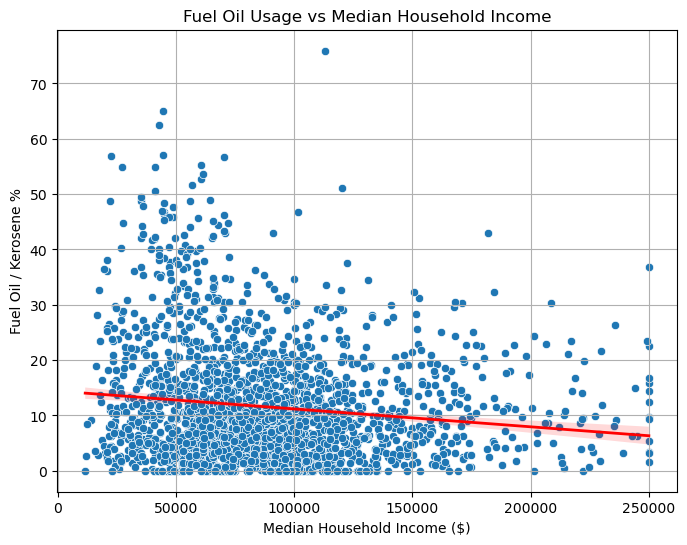

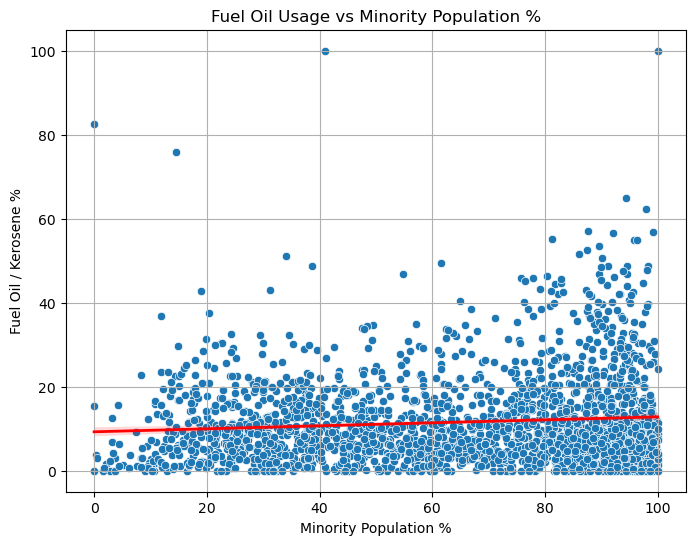

In [76]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("nyc_fuel_income_minority_clean.csv")

# Ensure numeric columns are floats
numeric_cols = ["fuel_oil_pct", "median_household_income", "minority_pct"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Scatter plot: Fuel oil % vs Median Income
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="median_household_income", y="fuel_oil_pct")
sns.regplot(data=df, x="median_household_income", y="fuel_oil_pct",
            scatter=False, color='red', line_kws={"linewidth":2})
plt.title("Fuel Oil Usage vs Median Household Income")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Fuel Oil / Kerosene %")
plt.grid(True)
plt.savefig("fuel_vs_income.png")  # saves image
plt.show()

# Scatter plot: Fuel oil % vs Minority %
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="minority_pct", y="fuel_oil_pct")
sns.regplot(data=df, x="minority_pct", y="fuel_oil_pct",
            scatter=False, color='red', line_kws={"linewidth":2})
plt.title("Fuel Oil Usage vs Minority Population %")
plt.xlabel("Minority Population %")
plt.ylabel("Fuel Oil / Kerosene %")
plt.grid(True)
plt.savefig("fuel_vs_minority.png")
plt.show()